# GNN Validation Experiment v6
## Classical Comparison · Hyperparameter Tuning · Ablation · Interpretability
**Cells**: A Config · B Load · C Assemble · D Norm · E Adjacency · F GNN · G Utils · H Classical · I HPT · J Final GNN · K Ablation · L Interpretability · M Comparison

In [1]:
# =========================================================
# Cell A — Imports & Configuration
# =========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found — run: pip install torch-geometric")

warnings.filterwarnings("ignore", category=UserWarning)

# ---------------------------------------------------------
# Canonical configuration (must match the pipeline)
# ---------------------------------------------------------

START_MONTH = "2014-01"
END_MONTH   = "2025-11"

MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL",
    "ES", "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]

COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)  # 27

ALL_CATS = [
    "TOTAL",
    "Food_drinks_tobacco",
    "Raw_materials",
    "Energy",
    "Chemicals",
    "Machinery_vehicles",
    "Other_manufactured",
]

N_CATS = len(ALL_CATS)  # 7

CEPII_COLS = [
    "comlang_ethno",
    "contig",
    "smctry",
    "dist",
    "distcap",
    "distw",
    "distwces",
]

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

DATA_DIR = Path(
    "C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN"
)

MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"

IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ---------------------------------------------------------
# Experiment hyperparameters
# ---------------------------------------------------------

HIDDEN_DIM = 64
N_EPOCHS   = 50
LR         = 3e-4
GRAD_CLIP  = 1.0

# TARGET_SCALE computed later (Cell D)

HEADS   = 4
SEED    = 42

LOG_NODE_FEATURES = True

K_NEIGHBORS = 6     # CEPII-KNN adjacency
N_LAYERS    = 2     # GNN depth

# ---------------------------------------------------------
# Hyperparameter tuning
# ---------------------------------------------------------

HPT_TRIALS  = 12
HPT_EPOCHS  = 20

# ---------------------------------------------------------
# Classical baselines
# ---------------------------------------------------------

N_PAR_WORKERS = 4   # for ETS / ARIMA

# ---------------------------------------------------------
# Time splits
# ---------------------------------------------------------

TRAIN_END = pd.Timestamp("2022-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

# ---------------------------------------------------------
# Device
# ---------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device        : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N} | Categories: {N_CATS} | Directed edges: {N*(N-1)}")
print(f"LOG_NODE_FEATURES: {LOG_NODE_FEATURES} | K_NEIGHBORS: {K_NEIGHBORS} | N_LAYERS: {N_LAYERS} | HPT_TRIALS: {HPT_TRIALS}")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 

✓ PyTorch Geometric available
Device        : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27 | Categories: 7 | Directed edges: 702
LOG_NODE_FEATURES: True | K_NEIGHBORS: 6 | N_LAYERS: 2 | HPT_TRIALS: 12


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs
# Data is already fully clean — no imputation needed.
# ══════════════════════════════════════════════════════════════════════════════

# ── B.1 Trade CSV ─────────────────────────────────────────────────────────────
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
print(f"  Reporters  : {sorted(df_trade['reporter'].unique())}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

# ── B.2 Node feature CSVs (T × 27 each) ──────────────────────────────────────
node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"

node_dfs = {}   # stem → DataFrame(T, 27)
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df

total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
print(f"── Node feature CSVs ──")
print(f"  Files loaded : {len(node_dfs)}")
print(f"  Total NaNs   : {total_node_nans}")
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"  ✓ All clean\n")

# ── B.3 Graph feature CSVs (EURIBOR, VSTOXX — broadcast to all 27 cols) ──────
graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}   # stem → Series(T,)

for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    assert df.std(axis=1).max() < 1e-9, f"{p.name}: columns are not identical broadcasts!"
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)

print(f"── Graph feature CSVs ──")
print(f"  Files loaded : {len(graph_series)}  → {list(graph_series.keys())}\n")

# ── B.4 Edge feature CSV (CEPII bilateral static) ─────────────────────────────
edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
assert edge_csv.exists(), f"Edge feature CSV not found at {edge_csv}"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge feature CSV ──")
print(f"  Shape  : {df_edge.shape}")
print(f"  Cols   : {list(df_edge.columns)}")

── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  Reporters  : ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  NaNs       : 0 ✓

── Node feature CSVs ──
  Files loaded : 35
  Total NaNs   : 0
  ✓ All clean

── Graph feature CSVs ──
  Files loaded : 2  → ['euribor3m_monthly', 'vstoxx_monthly']

── Edge feature CSV ──
  Shape  : (100386, 11)
  Cols   : ['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly
# ══════════════════════════════════════════════════════════════════════════════

# ── C.1 Align all sources to a common monthly index ───────────────────────────
common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

# ── C.2 Node feature tensor (T, N, F_node) ────────────────────────────────────
node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)   # (T, N)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np = np.stack(node_arrays, axis=-1)   # (T, N, F_node)
F_node  = node_np.shape[2]

# ── C.3 Graph feature tensor → broadcast to all nodes ────────────────────────
graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)   # (T, F_graph)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)    # (T, N, F_graph)
node_plus_graph_np = np.concatenate([node_np, graph_broadcast], axis=-1)  # (T, N, F_total)
F_total = node_plus_graph_np.shape[2]

# ── C.4 Target tensor (T, E, C) ───────────────────────────────────────────────
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]   # 702 directed edges
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :]   # (T, E, C)

# ── C.5 Static edge features (E, F_edge) ──────────────────────────────────────
F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]

edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

# ── C.6 Convert to tensors ────────────────────────────────────────────────────
node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)   # (T, N, F_total)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)   # (E, F_edge)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)   # (T, E, C)

print(f"\n✓ Tensor assembly complete")
print(f"  node_feat_tensor : {node_feat_tensor.shape}  (T, N, F_total={F_total})")
print(f"  edge_feat_tensor : {edge_feat_tensor.shape}  (E={E}, F_edge={F_edge})")
print(f"  target_tensor    : {target_tensor.shape}  (T, E, C={N_CATS})")
print(f"  NaNs in node features: {torch.isnan(node_feat_tensor).sum().item()}")
print(f"  NaNs in targets      : {torch.isnan(target_tensor).sum().item()}")

Common time range: 2014-01-01 → 2025-11-01  (T=143)

✓ Tensor assembly complete
  node_feat_tensor : torch.Size([143, 27, 37])  (T, N, F_total=37)
  edge_feat_tensor : torch.Size([702, 7])  (E=702, F_edge=7)
  target_tensor    : torch.Size([143, 702, 7])  (T, E, C=7)
  NaNs in node features: 0
  NaNs in targets      : 868


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Temporal Split + Normalization  (v4)
#
# Changes from v3:
#  • Node features: per-node per-feature z-score (not pooled across all nodes)
#  • Node features: optional log1p of strictly-positive features before z-score
#  • Edge distances: log1p before min-max (dist, distcap, distw, distwces)
#  • TARGET_SCALE: computed as 99th-percentile of log1p(train targets), not hardcoded
#  • detransform() helper added for converting predictions back to EUR
# ══════════════════════════════════════════════════════════════════════════════

# ── D.1 Strict temporal split on TARGET timestamp ─────────────────────────────
train_idx = [t for t in range(len(common_time) - 1) if common_time[t + 1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time) - 1) if TRAIN_END < common_time[t + 1] <= VAL_END]
test_idx  = [t for t in range(len(common_time) - 1) if common_time[t + 1] > VAL_END]

print('=== Temporal Split (target-based) ===')
print(f'Train : {len(train_idx):3d} steps  targets up to {common_time[train_idx[-1]+1].date()}')
print(f'Val   : {len(val_idx):3d} steps  targets {common_time[val_idx[0]+1].date()} → {common_time[val_idx[-1]+1].date()}')
print(f'Test  : {len(test_idx):3d} steps  targets from {common_time[test_idx[0]+1].date()}')
assert common_time[train_idx[-1] + 1] <= TRAIN_END, 'Boundary leak: last train target in val'
assert common_time[val_idx[0]   + 1] >  TRAIN_END, 'Boundary leak: first val target in train'
print('✓ No boundary leak')

# ── D.2 Optional log-transform of node features ───────────────────────────────
# Only applies log1p to features whose minimum value in the training set is > 0.
# Features that can be zero or negative (e.g. bond yields, CPI changes) are left
# in levels — log is undefined or misleading for them.
if LOG_NODE_FEATURES:
    train_min_per_feat = (
        node_feat_tensor[train_idx]
        .reshape(-1, F_total)
        .min(dim=0).values
    )   # (F,)
    log_mask = (train_min_per_feat > 0)   # True → safe to log
    node_feat_raw = node_feat_tensor.clone()
    node_feat_raw[:, :, log_mask] = torch.log1p(node_feat_tensor[:, :, log_mask])
    print(f'Log-transforming {log_mask.sum().item()}/{F_total} strictly-positive node features')
else:
    node_feat_raw = node_feat_tensor
    log_mask      = None
    print('No log transform applied to node features')

# ── D.3 Per-node, per-feature z-score normalization ───────────────────────────
# Mean and std are computed per (country, feature) over training timesteps only.
# This preserves the different scales across countries (Malta vs Germany) and
# across features (GDP vs bond yield), unlike pooling all nodes into one stat.
train_data = node_feat_raw[train_idx]        # (T_train, N, F)
feat_mean  = train_data.mean(dim=0)          # (N, F)
feat_std   = train_data.std(dim=0).clamp(min=1e-8)   # (N, F)
node_feat_norm = (node_feat_raw - feat_mean) / feat_std   # (T, N, F)  broadcast over T

print(f'Node feat mean shape: {feat_mean.shape}  (per-node per-feature)')
print(f'NaNs after node norm : {torch.isnan(node_feat_norm).sum().item()}')

# ── D.4 Edge feature processing: log1p distances → min-max ───────────────────
# Distance features span multiple orders of magnitude across EU pairs.
# log1p compresses the tail before min-max, making the normalization more uniform.
# Binary/similarity features (comlang, contig, smctry) are left as-is.
DISTANCE_FEAT_COLS    = ['dist', 'distcap', 'distw', 'distwces']
SIMILARITY_FEAT_COLS  = ['comlang_ethno', 'contig', 'smctry']
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]
SIMILARITY_FEAT_INDICES = [CEPII_COLS.index(c) for c in SIMILARITY_FEAT_COLS]

edge_feat_proc = edge_feat_tensor.clone()
for col_idx in DISTANCE_FEAT_INDICES:
    edge_feat_proc[:, col_idx] = torch.log1p(edge_feat_proc[:, col_idx])

edge_feat_min   = edge_feat_proc.min(dim=0).values
edge_feat_max   = edge_feat_proc.max(dim=0).values
edge_feat_range = (edge_feat_max - edge_feat_min).clamp(min=1e-8)
edge_feat_norm  = (edge_feat_proc - edge_feat_min) / edge_feat_range   # (E, F_edge)

# ── D.5 Target: log1p → scale by training-set 99th percentile ────────────────
# Using a quantile instead of max makes the scale robust to outlier trade spikes.
# The 99th percentile of log1p(train targets) captures the effective upper range
# without being pulled by extreme values.
target_log       = torch.log1p(target_tensor.clamp(min=0))   # (T, E, C)
train_target_log = target_log[train_idx]
valid_train_log  = train_target_log[~torch.isnan(train_target_log)]
TARGET_SCALE     = float(valid_train_log.quantile(0.99))
target_scaled    = target_log / TARGET_SCALE

print(f'\nTARGET_SCALE (99th pct of log1p(train targets)): {TARGET_SCALE:.4f}')
valid_vals = target_scaled[~torch.isnan(target_scaled)]
print(f'Target stats after log1p / {TARGET_SCALE:.4f}:')
print(f'  Mean {valid_vals.mean():.4f}  Std {valid_vals.std():.4f}  '
      f'Min {valid_vals.min():.4f}  Max {valid_vals.max():.4f}')

# ── D.6 Detransform helper ────────────────────────────────────────────────────
def detransform(pred_scaled):
    """Convert model output (scaled) → EUR trade flow units via expm1.
    pred_scaled can be a tensor or numpy array.
    """
    if isinstance(pred_scaled, torch.Tensor):
        return torch.expm1(pred_scaled.clamp(min=-30) * TARGET_SCALE)
    import numpy as np
    return np.expm1(np.clip(pred_scaled, -30, None) * TARGET_SCALE)

print('\n✓ Normalization and detransform complete')


=== Temporal Split (target-based) ===
Train : 107 steps  targets up to 2022-12-01
Val   :  12 steps  targets 2023-01-01 → 2023-12-01
Test  :  23 steps  targets from 2024-01-01
✓ No boundary leak
Log-transforming 8/37 strictly-positive node features
Node feat mean shape: torch.Size([27, 37])  (per-node per-feature)
NaNs after node norm : 0

TARGET_SCALE (99th pct of log1p(train targets)): 21.2947
Target stats after log1p / 21.2947:
  Mean 0.6998  Std 0.1976  Min 0.0000  Max 1.1210

✓ Normalization and detransform complete


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — CEPII Adjacency + Self-Loop Policy  (v6)
# Single adjacency used throughout: KNN-composite (best from v4 sweep).
# Self-loop policy identical to v4 (literature-based).
# ══════════════════════════════════════════════════════════════════════════════

from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv

CONV_NEEDS_SELF_LOOPS = {GCNConv, GATv2Conv, TransformerConv}   # SAGEConv excluded
EDGE_AWARE_CONVS      = {GATv2Conv, TransformerConv}

edge_pair_to_idx = {pair: idx for idx, pair in enumerate(edge_pairs)}

edge_index_pred = torch.tensor(
    [[i for i,j in edge_pairs],[j for i,j in edge_pairs]], dtype=torch.long
)

# Distance column indices (log1p was applied in Cell D before min-max)
DISTANCE_FEAT_COLS    = ['dist','distcap','distw','distwces']
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]

# ── KNN-composite: K nearest by composite CEPII similarity ───────────────────
# All 7 CEPII features on [0,1] after Cell D normalization.
# Distance features flipped (1-x) so higher = more similar.
composite_score = {}
for e_idx, (i, j) in enumerate(edge_pairs):
    vec = edge_feat_norm[e_idx].clone()
    for col_idx in DISTANCE_FEAT_INDICES:
        vec[col_idx] = 1.0 - vec[col_idx]
    composite_score[(i, j)] = float(vec.mean())

cepii_pairs = []
for i in range(N):
    by_score = sorted(
        [(composite_score.get((i,j), -1.0), j) for j in range(N) if i != j],
        reverse=True
    )[:K_NEIGHBORS]
    cepii_pairs.extend([(i, j) for _, j in by_score])

DEFAULT_ADJ_PAIRS = cepii_pairs   # used by all cells below

def build_mp_graph(pairs, conv_cls):
    """Build (edge_index_mp, edge_attr_mp) with self-loops for appropriate conv types."""
    ei = torch.tensor([[p[0] for p in pairs],[p[1] for p in pairs]], dtype=torch.long)
    ea = torch.stack([edge_feat_norm[edge_pair_to_idx[p]] for p in pairs])
    if conv_cls in CONV_NEEDS_SELF_LOOPS:
        sl = torch.arange(N, dtype=torch.long)
        ei = torch.cat([ei, torch.stack([sl, sl])], dim=1)
        ea = torch.cat([ea, torch.zeros(N, F_edge)], dim=0)
    return ei, ea

ARCH_LR = {GCNConv:3e-4, GATv2Conv:1e-4, SAGEConv:3e-4, TransformerConv:1e-4}

print(f"KNN-composite adjacency: {len(cepii_pairs)} directed edges (K={K_NEIGHBORS}/source)")
print("✓ Adjacency setup complete")

KNN-composite adjacency: 162 directed edges (K=6/source)
✓ Adjacency setup complete


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — PlugAndPlayGNN  (v6)
# n_layers is now a constructor parameter (supports 1/2/3 for layer-depth ablation).
# get_attention_weights() extracts GATv2 attention coefficients for interpretability.
# add_self_loops=False on all conv constructors — managed by build_mp_graph.
# ══════════════════════════════════════════════════════════════════════════════

def _build_conv_layer(conv_cls, H, heads=4, edge_dim=None):
    # Determine which edge dimension to use
    ed = edge_dim if edge_dim is not None else F_edge
    
    if conv_cls is TransformerConv:
        # TransformerConv does NOT support 'add_self_loops' in __init__
        return conv_cls(
            H, 
            H // heads, 
            heads=heads, 
            edge_dim=ed, 
            concat=True
        )
    
    elif conv_cls is GATv2Conv:
        # GATv2Conv supports 'add_self_loops'
        return conv_cls(
            H, 
            H // heads, 
            heads=heads, 
            edge_dim=ed, 
            concat=True, 
            add_self_loops=False # Managed externally in build_mp_graph
        )
        
    elif conv_cls is GCNConv:
        return conv_cls(H, H, add_self_loops=False)
        
    else:   # SAGEConv
        return conv_cls(H, H)


class PlugAndPlayGNN(nn.Module):
    def __init__(self, conv_cls, in_channels=37, hidden_dim=64, n_layers=2,
                 n_targets=7, edge_feat_dim=7, dropout=0.1, heads=4):
        super().__init__()
        self.conv_cls = conv_cls
        self.n_layers = n_layers
        H = hidden_dim

        self.encoder = nn.Linear(in_channels, H)
        self.convs    = nn.ModuleList([_build_conv_layer(conv_cls, H, heads, edge_feat_dim)
                                       for _ in range(n_layers)])
        self.lns      = nn.ModuleList([nn.LayerNorm(H) for _ in range(n_layers)])

        pred_in = 2 * H + edge_feat_dim
        self.link_predictor = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H // 2), nn.ReLU(),
            nn.Linear(H // 2, n_targets),
        )
        self.dropout = nn.Dropout(dropout)
        self._last_attn = None   # populated by get_attention_weights()

    def _conv_fwd(self, conv, h, ei, ea, return_attn=False):
        if self.conv_cls in EDGE_AWARE_CONVS:
            if return_attn:
                out, (ei_ret, alpha) = conv(h, ei, edge_attr=ea, return_attention_weights=True)
                self._last_attn = (ei_ret.cpu(), alpha.cpu())
                return out
            return conv(h, ei, edge_attr=ea)
        return conv(h, ei)

    def gnn_encode(self, x, ei, ea, return_attn=False):
        h = F.relu(self.encoder(x))
        for layer_i, (conv, ln) in enumerate(zip(self.convs, self.lns)):
            h_res = h
            capture = return_attn and (layer_i == len(self.convs) - 1)
            h = self._conv_fwd(conv, h, ei, ea, return_attn=capture)
            h = ln(h); h = F.relu(h); h = self.dropout(h); h = h + h_res
        return h

    def forward(self, x, ei_mp, ea_mp, ei_pred, ea_pred, return_attn=False):
        h        = self.gnn_encode(x, ei_mp, ea_mp, return_attn=return_attn)
        src, dst = ei_pred
        return self.link_predictor(torch.cat([h[src], h[dst], ea_pred], dim=-1))

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


if HAS_PYG:
    print("PlugAndPlayGNN params (H=64, n_layers=2):")
    for cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
        m = PlugAndPlayGNN(cls, F_total, HIDDEN_DIM, N_LAYERS, N_CATS, F_edge)
        print(f"  {cls.__name__:<20}: {m.count_params():>8,}  LR={ARCH_LR[cls]}")

PlugAndPlayGNN params (H=64, n_layers=2):
  GCNConv             :   22,023  LR=0.0003
  GATv2Conv           :   31,495  LR=0.0001
  SAGEConv            :   30,215  LR=0.0003
  TransformerConv     :   47,879  LR=0.0001


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — Training Utilities  (v6)
# run_config(): single train+eval pass for HPT; returns final val MSE + model.
# predict_all_val(): collects (n_val, E, C) predictions for comparison.
# ══════════════════════════════════════════════════════════════════════════════

def run_config(config, n_epochs=N_EPOCHS, verbose=False):
    """
    Train a PlugAndPlayGNN from a config dict; return (final_val_mse, model).
    config keys: conv_cls, lr, hidden_dim, n_layers, dropout, weight_decay, heads
    """
    conv_cls    = config['conv_cls']
    hidden_dim  = config.get('hidden_dim',  HIDDEN_DIM)
    n_layers    = config.get('n_layers',    N_LAYERS)
    dropout     = config.get('dropout',     0.1)
    weight_decay= config.get('weight_decay',1e-5)
    lr          = config.get('lr',          ARCH_LR[conv_cls])
    heads       = config.get('heads',       HEADS)
    adj_pairs   = config.get('adj_pairs',   DEFAULT_ADJ_PAIRS)
    node_feats  = config.get('node_feats',  node_feat_norm)
    edge_pred   = config.get('edge_pred',   edge_feat_norm)

    torch.manual_seed(SEED)
    model = PlugAndPlayGNN(conv_cls, F_total, hidden_dim, n_layers,
                           N_CATS, F_edge, dropout, heads).to(DEVICE)
    opt  = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.MSELoss()

    ei_mp, ea_mp = build_mp_graph(adj_pairs, conv_cls)
    ei_mp_d  = ei_mp.to(DEVICE); ea_mp_d  = ea_mp.to(DEVICE)
    ei_pred_d= edge_index_pred.to(DEVICE); ea_pred_d = edge_pred.to(DEVICE)

    train_hist, val_hist = [], []
    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss = 0.0
        for t in train_idx:
            x     = node_feats[t].to(DEVICE)
            y     = target_scaled[t+1].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            ep_loss += loss.item()
        train_hist.append(ep_loss / len(train_idx))

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for t in val_idx:
                x     = node_feats[t].to(DEVICE)
                y     = target_scaled[t+1].to(DEVICE)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v_loss += crit(pred[valid], y[valid]).item()
        val_hist.append(v_loss / len(val_idx))

        if verbose and epoch % 10 == 0:
            print(f"  epoch {epoch:3d}/{n_epochs}  train={train_hist[-1]:.5f}  val={val_hist[-1]:.5f}")

    return val_hist[-1], model, train_hist, val_hist


def predict_all_val(model, config=None):
    """
    Run inference on all val steps; return (n_val, E, C) numpy array.
    Predictions are in target_scaled space for direct MSE comparison with classicals.
    """
    adj_pairs  = (config or {}).get('adj_pairs',  DEFAULT_ADJ_PAIRS)
    conv_cls   = model.conv_cls
    node_feats = (config or {}).get('node_feats', node_feat_norm)
    edge_pred  = (config or {}).get('edge_pred',  edge_feat_norm)

    ei_mp, ea_mp = build_mp_graph(adj_pairs, conv_cls)
    ei_mp_d  = ei_mp.to(DEVICE); ea_mp_d  = ea_mp.to(DEVICE)
    ei_pred_d= edge_index_pred.to(DEVICE); ea_pred_d = edge_pred.to(DEVICE)

    model.eval()
    preds = []
    with torch.no_grad():
        for t in val_idx:
            x    = node_feats[t].to(DEVICE)
            pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            preds.append(pred.cpu().numpy())
    return np.stack(preds, axis=0)   # (n_val, E, C)


def log_ratio_score(val_a, val_b):
    return float(np.log(val_b / val_a))


print("✓ Training utilities defined")

✓ Training utilities defined


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Classical Baseline Models
#
# Fits 5 models on each of 702 edges × 7 categories = 4,914 time series.
# All predictions are in target_scaled space (log1p / TARGET_SCALE) so MSE
# is directly comparable to the GNN val MSE.
#
# Models:
#  1. Naive          — last observed training value (O(1))
#  2. Seasonal Naive — value from 12 months prior (O(1))
#  3. ETS            — simple exponential smoothing (statsmodels, parallelised)
#  4. ARIMA(1,1,1)   — fixed order, no AIC search (parallelised)
#  5. Ridge+lag      — lags {1,2,3,6,12} + src/dst node features + edge features
#                      (gives Ridge roughly the same information as the GNN)
# ══════════════════════════════════════════════════════════════════════════════

import warnings
import time
from joblib import Parallel, delayed
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# ── Index setup ──────────────────────────────────────────────────────────────
# train_target_times[i] is the time index of the i-th training TARGET
# (i.e. what the GNN predicts as y = target_scaled[t+1] for t in train_idx)
train_target_times = [t + 1 for t in train_idx]
val_target_times   = [t + 1 for t in val_idx]
n_val              = len(val_target_times)

target_np  = target_scaled.numpy()   # (T, E, C) — scaled log1p space
node_np    = node_feat_norm.numpy()  # (T, N, F)
edge_np    = edge_feat_norm.numpy()  # (E, F_edge)
val_actual = target_np[val_target_times]   # (n_val, E, C) — ground truth

# ── NaN-safe series extraction ────────────────────────────────────────────────
def extract_train_series(e, c):
    s = target_np[train_target_times, e, c].copy()
    # forward-fill then back-fill NaNs
    mask = np.isnan(s)
    if mask.all():
        return np.zeros(len(s))
    idx   = np.arange(len(s))
    valid = idx[~mask]
    s     = np.interp(idx, valid, s[valid])
    return s.astype(np.float64)

tasks = [(e, c) for e in range(E) for c in range(N_CATS)]

# ── 1. Naive ─────────────────────────────────────────────────────────────────
print("1/5  Naive...")
naive_preds = np.full((n_val, E, N_CATS), np.nan)
for e in range(E):
    for c in range(N_CATS):
        s = target_np[train_target_times, e, c]
        non_nan = s[~np.isnan(s)]
        last_val = non_nan[-1] if len(non_nan) > 0 else 0.0
        naive_preds[:, e, c] = last_val

# ── 2. Seasonal Naive ─────────────────────────────────────────────────────────
print("2/5  Seasonal Naive (lag-12)...")
snaive_preds = np.full((n_val, E, N_CATS), np.nan)
for v_i, v_t in enumerate(val_target_times):
    lag12 = v_t - 12
    if lag12 >= 0:
        snaive_preds[v_i] = target_np[lag12]
    else:
        snaive_preds[v_i] = naive_preds[v_i]

# ── 3. ETS ─────────────────────────────────────────────────────────────────────
print("3/5  ETS (parallel)...")
def fit_ets(e, c):
    s = extract_train_series(e, c)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit = SimpleExpSmoothing(s, initialization_method='estimated').fit(optimized=True)
            return e, c, fit.forecast(n_val).tolist()
    except Exception:
        return e, c, [s[-1]] * n_val

t0 = time.time()
ets_preds = np.full((n_val, E, N_CATS), np.nan)
for e, c, fc in Parallel(n_jobs=N_PAR_WORKERS, prefer='threads')(delayed(fit_ets)(e,c) for e,c in tasks):
    ets_preds[:, e, c] = fc
print(f"   done  {time.time()-t0:.1f}s")

# ── 4. ARIMA(1,1,1) ──────────────────────────────────────────────────────────
print("4/5  ARIMA(1,1,1) fixed order (parallel)...")
def fit_arima(e, c):
    s = extract_train_series(e, c)
    if np.std(s) < 1e-8:
        return e, c, [float(s[-1])] * n_val
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit = SARIMAX(s, order=(1,1,1), trend='n',
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, maxiter=100, method='lbfgs')
            return e, c, list(fit.forecast(steps=n_val))
    except Exception:
        return e, c, [float(s[-1])] * n_val

t0 = time.time()
arima_preds = np.full((n_val, E, N_CATS), np.nan)
for e, c, fc in Parallel(n_jobs=N_PAR_WORKERS, prefer='threads')(delayed(fit_arima)(e,c) for e,c in tasks):
    arima_preds[:, e, c] = fc
print(f"   done  {time.time()-t0:.1f}s")

# ── 5. Ridge + lag features + node/edge features ─────────────────────────────
# Feature vector: lags {1,2,3,6,12} of target + src node feats + dst node feats + edge feats
# This gives Ridge the same information access as the GNN (approximately).
print("5/5  Ridge+lag (parallel)...")
LAGS = [1, 2, 3, 6, 12]

def _lag_val(target_np, t, lag, e, c):
    idx = t + 1 - lag
    v   = target_np[idx, e, c] if idx >= 0 else np.nan
    return 0.0 if np.isnan(v) else float(v)

def fit_ridge(e, c):
    src_i, dst_i = edge_pairs[e]
    X_tr, y_tr = [], []
    for t in train_idx:
        y_val = target_np[t+1, e, c]
        if np.isnan(y_val):
            continue
        lags = [_lag_val(target_np, t, lag, e, c) for lag in LAGS]
        feat = np.concatenate([lags, node_np[t, src_i], node_np[t, dst_i], edge_np[e]])
        X_tr.append(feat); y_tr.append(y_val)
    if len(y_tr) < 5:
        return e, c, [float(target_np[train_target_times[-1], e, c])] * n_val
    X_arr = np.nan_to_num(np.array(X_tr, dtype=np.float32), nan=0.0)
    sc = StandardScaler().fit(X_arr)
    mdl = Ridge(alpha=1.0).fit(sc.transform(X_arr), y_tr)
    fc = []
    for t in val_idx:
        lags = [_lag_val(target_np, t, lag, e, c) for lag in LAGS]
        feat = np.concatenate([lags, node_np[t, src_i], node_np[t, dst_i], edge_np[e]])
        feat = np.nan_to_num(feat, nan=0.0).reshape(1, -1)
        fc.append(float(mdl.predict(sc.transform(feat))[0]))
    return e, c, fc

t0 = time.time()
ridge_preds = np.full((n_val, E, N_CATS), np.nan)
for e, c, fc in Parallel(n_jobs=-1, prefer='threads')(delayed(fit_ridge)(e,c) for e,c in tasks):
    ridge_preds[:, e, c] = fc
print(f"   done  {time.time()-t0:.1f}s")

# ── MSE helpers ───────────────────────────────────────────────────────────────
def mse(preds, actuals):
    valid = ~np.isnan(actuals)
    return float(np.mean((preds[valid] - actuals[valid])**2)) if valid.any() else np.nan

def mse_per_cat(preds, actuals):
    return {cat: mse(preds[:,:,c], actuals[:,:,c]) for c, cat in enumerate(ALL_CATS)}

def mse_per_country(preds, actuals):
    """Mean MSE over all edges involving each country (as src or dst)."""
    results = {}
    for i, country in enumerate(COUNTRIES):
        edges_i = [e for e, (s, d) in enumerate(edge_pairs) if s==i or d==i]
        results[country] = mse(preds[:,edges_i,:], actuals[:,edges_i,:])
    return results

classical_preds = {
    'Naive'     : naive_preds,
    'Seas.Naive': snaive_preds,
    'ETS'       : ets_preds,
    'ARIMA(111)': arima_preds,
    'Ridge+lag' : ridge_preds,
}
classical_mse = {name: mse(p, val_actual) for name, p in classical_preds.items()}
classical_mse_cat = {name: mse_per_cat(p, val_actual) for name, p in classical_preds.items()}
classical_mse_ctr = {name: mse_per_country(p, val_actual) for name, p in classical_preds.items()}

print(f"\n{'Model':<14}  {'Overall MSE':>12}")
print("─" * 30)
for name, val in classical_mse.items():
    print(f"  {name:<12}  {val:>12.5f}")
print("\n✓ Classical baselines complete")

1/5  Naive...
2/5  Seasonal Naive (lag-12)...
3/5  ETS (parallel)...
   done  23.0s
4/5  ARIMA(1,1,1) fixed order (parallel)...
   done  473.9s
5/5  Ridge+lag (parallel)...
   done  59.9s

Model            Overall MSE
──────────────────────────────
  Naive              0.00518
  Seas.Naive             nan
  ETS                0.00360
  ARIMA(111)         0.00358
  Ridge+lag          0.02793

✓ Classical baselines complete


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Hyperparameter Tuning  (v6)
#
# Random search: HPT_TRIALS configs per architecture, HPT_EPOCHS each.
# Tunes: lr, hidden_dim, dropout, weight_decay, n_layers.
# GATv2 additionally tunes: heads.
#
# "Same parameter budget" table: reports param count per config so
# comparisons at equal model capacity are possible.
# "Same training budget": all architectures trained for N_EPOCHS epochs
# with their best HPT config.
# ══════════════════════════════════════════════════════════════════════════════

import random as _rng

def sample_config(conv_cls, seed):
    r = _rng.Random(seed)
    cfg = {
        'conv_cls'    : conv_cls,
        'lr'          : r.choice([5e-5, 1e-4, 3e-4, 1e-3]),
        'hidden_dim'  : r.choice([32, 64, 128]),
        'dropout'     : r.choice([0.0, 0.1, 0.2]),
        'weight_decay': r.choice([0.0, 1e-5, 1e-4]),
        'n_layers'    : r.choice([1, 2, 3]),
        'heads'       : r.choice([2, 4, 8]) if conv_cls in EDGE_AWARE_CONVS else HEADS,
    }
    return cfg

hpt_results  = {}   # {arch_name: {'best_cfg': ..., 'best_val': ..., 'all_trials': [...]}}
best_configs = {}   # {arch_name: config}

for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    name   = conv_cls.__name__
    trials = []
    print(f"\n── HPT: {name}  ({HPT_TRIALS} trials × {HPT_EPOCHS} epochs) ──")

    for t in range(HPT_TRIALS):
        cfg        = sample_config(conv_cls, seed=SEED + t * 100)
        val_mse, model, _, _ = run_config(cfg, n_epochs=HPT_EPOCHS)
        n_params   = model.count_params()
        trials.append({'config': cfg, 'val_mse': val_mse, 'n_params': n_params})
        print(f"  trial {t+1:2d}/{HPT_TRIALS}  val={val_mse:.5f}  "
              f"params={n_params:,}  lr={cfg['lr']}  H={cfg['hidden_dim']}  "
              f"layers={cfg['n_layers']}  drop={cfg['dropout']}")

    best = min(trials, key=lambda x: x['val_mse'])
    hpt_results[name]  = {'best': best, 'trials': trials}
    best_configs[name] = best['config']
    print(f"  → BEST: val={best['val_mse']:.5f}  "
          f"params={best['n_params']:,}  config={best['config']}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'═'*80}")
print("  HPT SUMMARY")
print(f"{'Architecture':<22}  {'BestVal':>8}  {'Params':>8}  "
      f"{'LR':>6}  {'H':>4}  {'Layers':>6}  {'Drop':>5}  {'WD':>7}  {'Heads':>5}")
print("─" * 80)
for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    name = conv_cls.__name__
    b    = hpt_results[name]['best']
    cfg  = b['config']
    print(f"  {name:<20}  {b['val_mse']:>8.5f}  {b['n_params']:>8,}  "
          f"  {cfg['lr']:>6}  {cfg['hidden_dim']:>4}  {cfg['n_layers']:>6}  "
          f"{cfg['dropout']:>5}  {cfg['weight_decay']:>7}  {cfg.get('heads','-'):>5}")
print(f"{'═'*80}")

# ── Param budget equalization ─────────────────────────────────────────────────
# Identify the smallest param budget among best configs;
# note which architectures are above it (and by how much).
min_params = min(hpt_results[n]['best']['n_params']
                 for n in [c.__name__ for c in [GCNConv,GATv2Conv,SAGEConv,TransformerConv]])
print(f"\nSmallest best-config param count: {min_params:,}")
print("Param budget overage per architecture (for 'same budget' comparison):")
for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    name = conv_cls.__name__
    n_p  = hpt_results[name]['best']['n_params']
    print(f"  {name:<22}: {n_p:>8,}  ({n_p/min_params:.2f}x)")
print("\n✓ HPT complete")


── HPT: GCNConv  (12 trials × 20 epochs) ──
  trial  1/12  val=0.06848  params=5,287  lr=5e-05  H=32  layers=1  drop=0.2
  trial  2/12  val=0.02801  params=6,407  lr=0.001  H=32  layers=2  drop=0.1
  trial  3/12  val=0.01914  params=7,527  lr=0.0003  H=32  layers=3  drop=0.1
  trial  4/12  val=0.06849  params=5,287  lr=5e-05  H=32  layers=1  drop=0.2
  trial  5/12  val=0.02564  params=22,023  lr=0.0003  H=64  layers=2  drop=0.2
  trial  6/12  val=0.03799  params=5,287  lr=0.001  H=32  layers=1  drop=0.0
  trial  7/12  val=0.02503  params=22,023  lr=0.0003  H=64  layers=2  drop=0.2
  trial  8/12  val=0.04205  params=17,735  lr=0.001  H=64  layers=1  drop=0.0
  trial  9/12  val=0.03850  params=17,735  lr=5e-05  H=64  layers=1  drop=0.0
  trial 10/12  val=0.03088  params=5,287  lr=0.001  H=32  layers=1  drop=0.2
  trial 11/12  val=0.02801  params=6,407  lr=0.0001  H=32  layers=2  drop=0.1
  trial 12/12  val=0.03674  params=6,407  lr=5e-05  H=32  layers=2  drop=0.1
  → BEST: val=0.01914  

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell J — Final GNN Training with Best HPT Configs  (v6)
# Trains each architecture for N_EPOCHS using its best HPT config.
# "Same training budget": all get N_EPOCHS epochs.
# "Same parameter budget": best_configs already selected to minimize val MSE;
#   use the param table from Cell I to interpret cross-architecture differences.
# ══════════════════════════════════════════════════════════════════════════════

gnn_results  = {}   # {arch_name: {'model', 'val_hist', 'preds', 'mse', 'mse_per_cat'}}
gnn_val_mse  = {}

for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    name = conv_cls.__name__
    cfg  = best_configs[name]
    print(f"\n── Training {name} ({N_EPOCHS} epochs, best HPT config) ──")
    val_mse, model, tr_hist, val_hist = run_config(cfg, n_epochs=N_EPOCHS, verbose=True)

    preds = predict_all_val(model, cfg)          # (n_val, E, C)
    cat_mse = {
        cat: mse(preds[:, :, c], val_actual[:, :, c]) 
        for c, cat in enumerate(ALL_CATS)
    }
    ctr_mse = mse_per_country(preds, val_actual)

    gnn_results[name] = {
        'model': model, 'config': cfg,
        'train_hist': tr_hist, 'val_hist': val_hist,
        'preds': preds, 'mse': val_mse,
        'mse_per_cat': cat_mse, 'mse_per_country': ctr_mse,
    }
    gnn_val_mse[name] = val_mse

# ── Save best overall GNN for interpretability ─────────────────────────────────
best_gnn_name  = min(gnn_val_mse, key=gnn_val_mse.get)
best_gnn_model = gnn_results[best_gnn_name]['model']
best_gnn_cfg   = gnn_results[best_gnn_name]['config']
print(f"\nBest GNN: {best_gnn_name}  val MSE = {gnn_val_mse[best_gnn_name]:.5f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'Architecture':<22}  {'Val MSE':>9}  {'Params':>8}")
print("─" * 45)
for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    name = conv_cls.__name__
    r    = gnn_results[name]
    print(f"  {name:<20}  {r['mse']:>9.5f}  {r['model'].count_params():>8,}")
print("\n✓ Final GNN training complete")


── Training GCNConv (50 epochs, best HPT config) ──
  epoch  10/50  train=0.02815  val=0.02377
  epoch  20/50  train=0.02490  val=0.01914
  epoch  30/50  train=0.02083  val=0.02040
  epoch  40/50  train=0.02079  val=0.02405
  epoch  50/50  train=0.01773  val=0.02575

── Training GATv2Conv (50 epochs, best HPT config) ──
  epoch  10/50  train=0.03008  val=0.02310
  epoch  20/50  train=0.02666  val=0.02267
  epoch  30/50  train=0.02207  val=0.02636
  epoch  40/50  train=0.01703  val=0.02685
  epoch  50/50  train=0.01476  val=0.02293

── Training SAGEConv (50 epochs, best HPT config) ──
  epoch  10/50  train=0.02020  val=0.02727
  epoch  20/50  train=0.01465  val=0.01874
  epoch  30/50  train=0.01397  val=0.01611
  epoch  40/50  train=0.01123  val=0.01854
  epoch  50/50  train=0.00947  val=0.01435

── Training TransformerConv (50 epochs, best HPT config) ──
  epoch  10/50  train=0.01613  val=0.01877
  epoch  20/50  train=0.01127  val=0.01369
  epoch  30/50  train=0.00927  val=0.01221
  e

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell K — Ablation Studies  (v6)
#
# All ablations use the best GNN architecture from Cell J.
# Each runs N_EPOCHS with the same best HPT config (same training budget).
#
# Ablation 1 — No node features       : replace node_feat_norm with zeros
# Ablation 2 — No edge feats in MP    : pass zero edge_attr to GNN conv layers
#              (topology preserved; only the edge-attribute signal is removed)
# Ablation 3 — No edge feats in decoder: replace ea_pred with zeros
#              (bilateral CEPII features removed from link predictor)
# Ablation 4 — No graph features       : remove EURIBOR/VSTOXX columns from nodes
#              (the 2 broadcast columns that were appended from graph_series)
# Ablation 5 — Layer depth             : 1-layer vs 2-layer vs 3-layer GNN
#              (tests whether local vs multi-hop structure matters)
# ══════════════════════════════════════════════════════════════════════════════

base_cfg  = best_gnn_cfg.copy()
abl_conv  = best_gnn_cfg['conv_cls']
ablation_results = {}

def run_ablation(label, cfg_override, description):
    cfg = {**base_cfg, **cfg_override}
    print(f"\n── Ablation: {label}")
    print(f"   {description}")
    val_mse, model, _, val_hist = run_config(cfg, n_epochs=N_EPOCHS)
    preds = predict_all_val(model, cfg)
    ablation_results[label] = {
        'mse': val_mse, 'preds': preds, 'val_hist': val_hist,
        'mse_per_cat': {cat: mse(preds[:,:,c], val_actual[:,:,c]) for c, cat in enumerate(ALL_CATS)},
    }
    score = log_ratio_score(val_mse, gnn_val_mse[best_gnn_name])
    print(f"   val MSE = {val_mse:.5f}  |  log-ratio vs full = {score:+.4f} "
          f"({'performance drops ✓ feature matters' if score > 0 else 'no degradation — feature is redundant'})")
    return val_mse

# ── Ablation 1: No node features ──────────────────────────────────────────────
blank_nodes = torch.zeros_like(node_feat_norm)
run_ablation(
    'No node features',
    {'node_feats': blank_nodes},
    "All node feature values replaced with zero — tests whether economic node features add signal."
)

# ── Ablation 2: No edge features in message passing ───────────────────────────
# Rebuild edge_attr tensors with zeros for the MP graph (topology unchanged)
orig_ea_builder = build_mp_graph
def build_mp_graph_no_ea(pairs, conv_cls):
    ei, ea = orig_ea_builder(pairs, conv_cls)
    return ei, torch.zeros_like(ea)

# Monkey-patch temporarily — save pairs+conv for predict_all_val
_orig_build = __builtins__   # not actually changing builtins, just running directly
ei_zero, ea_zero = build_mp_graph_no_ea(DEFAULT_ADJ_PAIRS, abl_conv)
# Rebuild graph dict without edge attributes
class _ZeroEA:
    """Wrapper so predict_all_val sees zeroed ea."""
    pass
# Simpler approach: include pre-built tensors in the config
abl2_cfg = {**base_cfg, '_ei_mp_override': ei_zero, '_ea_mp_override': ea_zero}

# For this ablation we call run_config directly with a patched predict function
# The cleanest approach: pass the zero ea tensors via a wrapper
torch.manual_seed(SEED)
model_abl2 = PlugAndPlayGNN(
    abl_conv, F_total, base_cfg.get('hidden_dim', HIDDEN_DIM),
    base_cfg.get('n_layers', N_LAYERS), N_CATS, F_edge,
    base_cfg.get('dropout', 0.1), base_cfg.get('heads', HEADS)
).to(DEVICE)
opt_abl2  = Adam(model_abl2.parameters(), lr=base_cfg.get('lr', ARCH_LR[abl_conv]),
                  weight_decay=base_cfg.get('weight_decay', 1e-5))
crit_abl2 = nn.MSELoss()

print("\n── Ablation: No edge features in message passing")
print("   Edge attr zeroed in GNN layers; topology and decoder edge features preserved.")

ei_mp_d   = ei_zero.to(DEVICE); ea_mp_d = ea_zero.to(DEVICE)
ei_pred_d = edge_index_pred.to(DEVICE); ea_pred_d = edge_feat_norm.to(DEVICE)
v_hist_abl2 = []
for epoch in range(1, N_EPOCHS + 1):
    model_abl2.train()
    for t in train_idx:
        x = node_feat_norm[t].to(DEVICE); y = target_scaled[t+1].to(DEVICE)
        valid = ~torch.isnan(y).any(dim=-1); opt_abl2.zero_grad()
        loss = crit_abl2(model_abl2(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)[valid], y[valid])
        loss.backward(); nn.utils.clip_grad_norm_(model_abl2.parameters(), GRAD_CLIP); opt_abl2.step()
    model_abl2.eval()
    v = 0.0
    with torch.no_grad():
        for t in val_idx:
            x = node_feat_norm[t].to(DEVICE); y = target_scaled[t+1].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            v += crit_abl2(model_abl2(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)[valid], y[valid]).item()
    v_hist_abl2.append(v / len(val_idx))

model_abl2.eval()
preds_abl2 = []
with torch.no_grad():
    for t in val_idx:
        preds_abl2.append(model_abl2(node_feat_norm[t].to(DEVICE), ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d).cpu().numpy())
preds_abl2 = np.stack(preds_abl2)
mse_abl2   = mse(preds_abl2, val_actual)
ablation_results['No MP edge features'] = {
    'mse': mse_abl2, 'preds': preds_abl2, 'val_hist': v_hist_abl2,
    'mse_per_cat': {cat: mse(preds[:,:,c], val_actual[:,:,c]) for c, cat in enumerate(ALL_CATS)},
}
score_abl2 = log_ratio_score(mse_abl2, gnn_val_mse[best_gnn_name])
print(f"   val MSE = {mse_abl2:.5f}  |  log-ratio = {score_abl2:+.4f}")

# ── Ablation 3: No edge features in decoder ───────────────────────────────────
zero_edge_pred = torch.zeros_like(edge_feat_norm)
run_ablation(
    'No decoder edge features',
    {'edge_pred': zero_edge_pred},
    "CEPII bilateral features zeroed in link predictor; MP edge features preserved."
)

# ── Ablation 4: No graph features (EURIBOR / VSTOXX) ─────────────────────────
# The last F_graph columns of node_feat_norm are broadcast graph features.
F_graph      = len(graph_series)
F_node_only  = F_total - F_graph
node_no_graph = node_feat_norm[:, :, :F_node_only]   # (T, N, F_node_only)
# Model needs in_channels adjusted — create a config override
run_ablation(
    'No graph features',
    {'node_feats': node_no_graph},
    f"EURIBOR/VSTOXX columns removed ({F_graph} features). in_channels={F_node_only}."
)
# Note: the above reuses F_total for in_channels which is wrong — fix inline:
# Re-run with corrected in_channels
torch.manual_seed(SEED)
no_graph_cfg  = {**base_cfg, 'node_feats': node_no_graph}
print(f"   (re-running with corrected in_channels={F_node_only})")
val_mse_ng, m_ng, _, vh_ng = run_config({**no_graph_cfg, '_in_channels': F_node_only},
                                          n_epochs=N_EPOCHS)
# run_config uses F_total hardcoded — override model creation:
torch.manual_seed(SEED)
m_ng2 = PlugAndPlayGNN(abl_conv, F_node_only, base_cfg.get('hidden_dim', HIDDEN_DIM),
                        base_cfg.get('n_layers', N_LAYERS), N_CATS, F_edge,
                        base_cfg.get('dropout', 0.1), base_cfg.get('heads', HEADS)).to(DEVICE)
opt_ng = Adam(m_ng2.parameters(), lr=base_cfg.get('lr', ARCH_LR[abl_conv]))
crit_ng= nn.MSELoss()
ei_ng, ea_ng = build_mp_graph(DEFAULT_ADJ_PAIRS, abl_conv)
ei_ng_d = ei_ng.to(DEVICE); ea_ng_d = ea_ng.to(DEVICE)
vh_ng2  = []
for epoch in range(1, N_EPOCHS + 1):
    m_ng2.train()
    for t in train_idx:
        x = node_no_graph[t].to(DEVICE); y = target_scaled[t+1].to(DEVICE)
        valid = ~torch.isnan(y).any(dim=-1); opt_ng.zero_grad()
        loss  = crit_ng(m_ng2(x, ei_ng_d, ea_ng_d, ei_pred_d, ea_pred_d)[valid], y[valid])
        loss.backward(); nn.utils.clip_grad_norm_(m_ng2.parameters(), GRAD_CLIP); opt_ng.step()
    m_ng2.eval(); v = 0.0
    with torch.no_grad():
        for t in val_idx:
            x = node_no_graph[t].to(DEVICE); y = target_scaled[t+1].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            v += crit_ng(m_ng2(x, ei_ng_d, ea_ng_d, ei_pred_d, ea_pred_d)[valid], y[valid]).item()
    vh_ng2.append(v / len(val_idx))
preds_ng = []
m_ng2.eval()
with torch.no_grad():
    for t in val_idx:
        preds_ng.append(m_ng2(node_no_graph[t].to(DEVICE), ei_ng_d, ea_ng_d, ei_pred_d, ea_pred_d).cpu().numpy())
preds_ng = np.stack(preds_ng); mse_ng = mse(preds_ng, val_actual)
ablation_results['No graph features'] = {'mse': mse_ng, 'preds': preds_ng, 'val_hist': vh_ng2,
    'mse_per_cat': {cat: mse(preds_ng[:,:,c], val_actual[:,:,c]) for c, cat in enumerate(ALL_CATS)}}
print(f"   No graph features  val MSE = {mse_ng:.5f}  log-ratio = {log_ratio_score(mse_ng, gnn_val_mse[best_gnn_name]):+.4f}")

# ── Ablation 5: Layer depth (1 / 2 / 3 layers) ────────────────────────────────
print("\n── Ablation: Layer depth (1 / 2 / 3)")
for n_l in [1, 2, 3]:
    run_ablation(f'Layers={n_l}', {'n_layers': n_l},
                 f"GNN depth={n_l}: tests local (1-hop) vs multi-hop trade structure.")

# ── Ablation summary ─────────────────────────────────────────────────────────
baseline_mse = gnn_val_mse[best_gnn_name]
print(f"\n{'Ablation':<28}  {'Val MSE':>9}  {'log-ratio':>10}  {'Verdict':>30}")
print("─" * 85)
print(f"  {'Full model (baseline)':<26}  {baseline_mse:>9.5f}  {'—':>10}")
for label, res in ablation_results.items():
    score  = log_ratio_score(res['mse'], baseline_mse)
    verdict= 'feature/depth matters ✓' if score > 0.01 else ('marginal' if score > 0 else 'redundant ✗')
    print(f"  {label:<26}  {res['mse']:>9.5f}  {score:>+10.4f}  {verdict:>30}")
print("\n✓ Ablation complete")


── Ablation: No node features
   All node feature values replaced with zero — tests whether economic node features add signal.
   val MSE = 0.00611  |  log-ratio vs full = +0.5608 (performance drops ✓ feature matters)

── Ablation: No edge features in message passing
   Edge attr zeroed in GNN layers; topology and decoder edge features preserved.
   val MSE = 0.01408  |  log-ratio = -0.2734

── Ablation: No decoder edge features
   CEPII bilateral features zeroed in link predictor; MP edge features preserved.
   val MSE = 0.01232  |  log-ratio vs full = -0.1403 (no degradation — feature is redundant)

── Ablation: No graph features
   EURIBOR/VSTOXX columns removed (2 features). in_channels=35.


RuntimeError: mat1 and mat2 shapes cannot be multiplied (27x35 and 37x32)

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell L — Interpretability  (v6)
#
# L1. Attention weights (GATv2): which edges receive most attention? Do
#     attention patterns reflect geography and known EU trade blocs?
# L2. Gradient × input attribution: which node features drive predictions?
#     Per-feature importance averaged over all val steps.
# L3. Country influence: mean absolute gradient per country (src and dst).
# L4. Per-category and per-country error breakdown.
# L5. Most/least predictable edges (sorted by val MSE).
# ══════════════════════════════════════════════════════════════════════════════

# Use the best GNN model from Cell J
model  = best_gnn_model
model.eval()
config = best_gnn_cfg
ei_mp, ea_mp = build_mp_graph(DEFAULT_ADJ_PAIRS, model.conv_cls)
ei_mp_d  = ei_mp.to(DEVICE); ea_mp_d  = ea_mp.to(DEVICE)
ei_pred_d= edge_index_pred.to(DEVICE); ea_pred_d = edge_feat_norm.to(DEVICE)

gnn_preds_val = gnn_results[best_gnn_name]['preds']   # (n_val, E, C)

# ── L1. Attention weights ─────────────────────────────────────────────────────
attn_available = model.conv_cls in EDGE_AWARE_CONVS
if attn_available:
    print("L1. Extracting attention weights (GATv2/Transformer)...")
    all_alphas = []
    for t in val_idx:
        x = node_feat_norm[t].to(DEVICE)
        with torch.no_grad():
            model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d, return_attn=True)
        if model._last_attn is not None:
            ei_attn, alpha = model._last_attn   # alpha: (E_mp, heads)
            all_alphas.append(alpha.mean(dim=-1))   # average over heads → (E_mp,)
    mean_alpha = torch.stack(all_alphas).mean(dim=0).numpy()   # (E_mp,)

    # Map back to 27×27 attention matrix (only for non-self-loop edges)
    n_mp_edges = ei_mp.shape[1]
    n_sl       = N if model.conv_cls in CONV_NEEDS_SELF_LOOPS else 0
    n_real     = n_mp_edges - n_sl
    attn_matrix = np.zeros((N, N))
    for k in range(n_real):
        src_k = int(ei_mp[0, k]); dst_k = int(ei_mp[1, k])
        attn_matrix[dst_k, src_k] = mean_alpha[k]   # dst receives from src

    # Top-10 attended directed pairs
    flat_attn = [(attn_matrix[d, s], COUNTRIES[s], COUNTRIES[d])
                 for s in range(N) for d in range(N) if s != d]
    flat_attn.sort(reverse=True)
    print("  Top-10 most attended directed pairs (src → dst):")
    for score, src_c, dst_c in flat_attn[:10]:
        print(f"    {src_c} → {dst_c}  attention = {score:.4f}")
else:
    attn_matrix = None
    print("L1. Attention weights: not available for this architecture (need GATv2/Transformer).")

# ── L2. Gradient × input attribution (feature importance) ────────────────────
print("\nL2. Gradient × input attribution...")
feat_importance = np.zeros(F_total)   # mean |grad × input| per feature
n_contrib = 0
for t in val_idx:
    x = node_feat_norm[t].clone().to(DEVICE).requires_grad_(True)
    y = target_scaled[t + 1].to(DEVICE)
    valid = ~torch.isnan(y).any(dim=-1)
    pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
    loss  = nn.MSELoss()(pred[valid], y[valid])
    loss.backward()
    if x.grad is not None:
        # attribution: (N, F) → mean absolute value over nodes
        attr = (x.grad.detach() * x.detach()).abs().mean(dim=0).cpu().numpy()
        feat_importance += attr
        n_contrib += 1
feat_importance /= max(n_contrib, 1)

# Sort by importance
feat_ranked = sorted(enumerate(feat_importance), key=lambda x: -x[1])
print("  Top-15 most important node features (gradient × input):")
for rank, (feat_idx, score) in enumerate(feat_ranked[:15], 1):
    name_parts = node_feat_names + graph_feat_names   # all feature names
    feat_name  = name_parts[feat_idx] if feat_idx < len(name_parts) else f"feat_{feat_idx}"
    print(f"  {rank:2d}. {feat_name:<30}  importance = {score:.5f}")

# ── L3. Country influence (gradient w.r.t. each country's node features) ──────
print("\nL3. Country influence (per-node mean absolute gradient)...")
country_importance = np.zeros(N)
for t in val_idx:
    x = node_feat_norm[t].clone().to(DEVICE).requires_grad_(True)
    y = target_scaled[t + 1].to(DEVICE)
    valid = ~torch.isnan(y).any(dim=-1)
    pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
    nn.MSELoss()(pred[valid], y[valid]).backward()
    if x.grad is not None:
        country_importance += x.grad.detach().abs().mean(dim=-1).cpu().numpy()
country_importance /= len(val_idx)

country_ranked = sorted(zip(COUNTRIES, country_importance), key=lambda x: -x[1])
print("  Country influence ranking (mean absolute gradient):")
for rank, (country, score) in enumerate(country_ranked, 1):
    bar = "█" * int(score / max(country_importance) * 20)
    print(f"  {rank:2d}. {country}  {score:.5f}  {bar}")

# ── L4. Per-edge MSE: most and least predictable ──────────────────────────────
print("\nL4. Most / least predictable edges (TOTAL category)...")
edge_mse_vals = [mse(gnn_preds_val[:, e, :], val_actual[:, e, :]) for e in range(E)]
edge_mse_arr  = np.array(edge_mse_vals)

sorted_edges = np.argsort(edge_mse_arr)
print("  10 easiest edges:")
for e in sorted_edges[:10]:
    s, d = edge_pairs[e]
    print(f"    {COUNTRIES[s]}→{COUNTRIES[d]}  MSE={edge_mse_arr[e]:.5f}")
print("  10 hardest edges:")
for e in sorted_edges[-10:][::-1]:
    s, d = edge_pairs[e]
    print(f"    {COUNTRIES[s]}→{COUNTRIES[d]}  MSE={edge_mse_arr[e]:.5f}")

# ── L5. Per-category error breakdown for best GNN ─────────────────────────────
print("\nL5. Per-category error breakdown:")
for c, cat in enumerate(ALL_CATS):
    cat_mse_gnn = mse(gnn_preds_val[:,:,c], val_actual[:,:,c])
    print(f"  {cat:<28}: GNN MSE = {cat_mse_gnn:.5f}")

# Store for Cell M
interp_results = {
    'feat_importance'    : feat_importance,
    'feat_names'         : node_feat_names + graph_feat_names,
    'country_importance' : dict(zip(COUNTRIES, country_importance)),
    'country_ranked'     : country_ranked,
    'edge_mse'           : edge_mse_arr,
    'attn_matrix'        : attn_matrix,
}
print("\n✓ Interpretability complete")

L1. Extracting attention weights (GATv2/Transformer)...
  Top-10 most attended directed pairs (src → dst):
    PT → ES  attention = 0.5749
    LU → FR  attention = 0.5435
    CY → RO  attention = 0.5315
    LU → AT  attention = 0.5221
    LU → DE  attention = 0.4813
    MT → SI  attention = 0.4496
    LU → NL  attention = 0.4471
    EE → LT  attention = 0.4347
    MT → IE  attention = 0.4192
    EE → SE  attention = 0.3944

L2. Gradient × input attribution...
  Top-15 most important node features (gradient × input):
   1. euribor3m_monthly               importance = 0.00022
   2. euribor3m_monthly               importance = 0.00016
   3. ppi_c25_monthly                 importance = 0.00014
   4. ppi_c22_monthly                 importance = 0.00012
   5. ppi_c14_monthly                 importance = 0.00011
   6. hicp_food_monthly               importance = 0.00011
   7. ppi_c30_monthly                 importance = 0.00011
   8. ppi_c13_monthly                 importance = 0.00010
   9. 

════════════════════════════════════════════════════════════════════════════════════════════════════
  MASTER COMPARISON TABLE — Val MSE in log1p / TARGET_SCALE space
════════════════════════════════════════════════════════════════════════════════════════════════════
Method                  Overall   vs Naive      TOTAL  Food_drin  Raw_mater     Energy  Chemicals  Machinery  Other_man
────────────────────────────────────────────────────────────────────────────────────────────────────
  Naive                 0.00518    +0.0000    0.00240    0.00451    0.00579    0.01621    0.00297    0.00170    0.00264 ◀ BEST
  Seas.Naive                nan       +nan        nan        nan        nan        nan        nan        nan        nan
  ARIMA(111)            0.00358    +0.3684    0.00223    0.00350    0.00413    0.01055    0.00146    0.00097    0.00223
  ETS                   0.00360    +0.3639    0.00225    0.00350    0.00415    0.01051    0.00144    0.00110    0.00223
  TransformerConv       

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


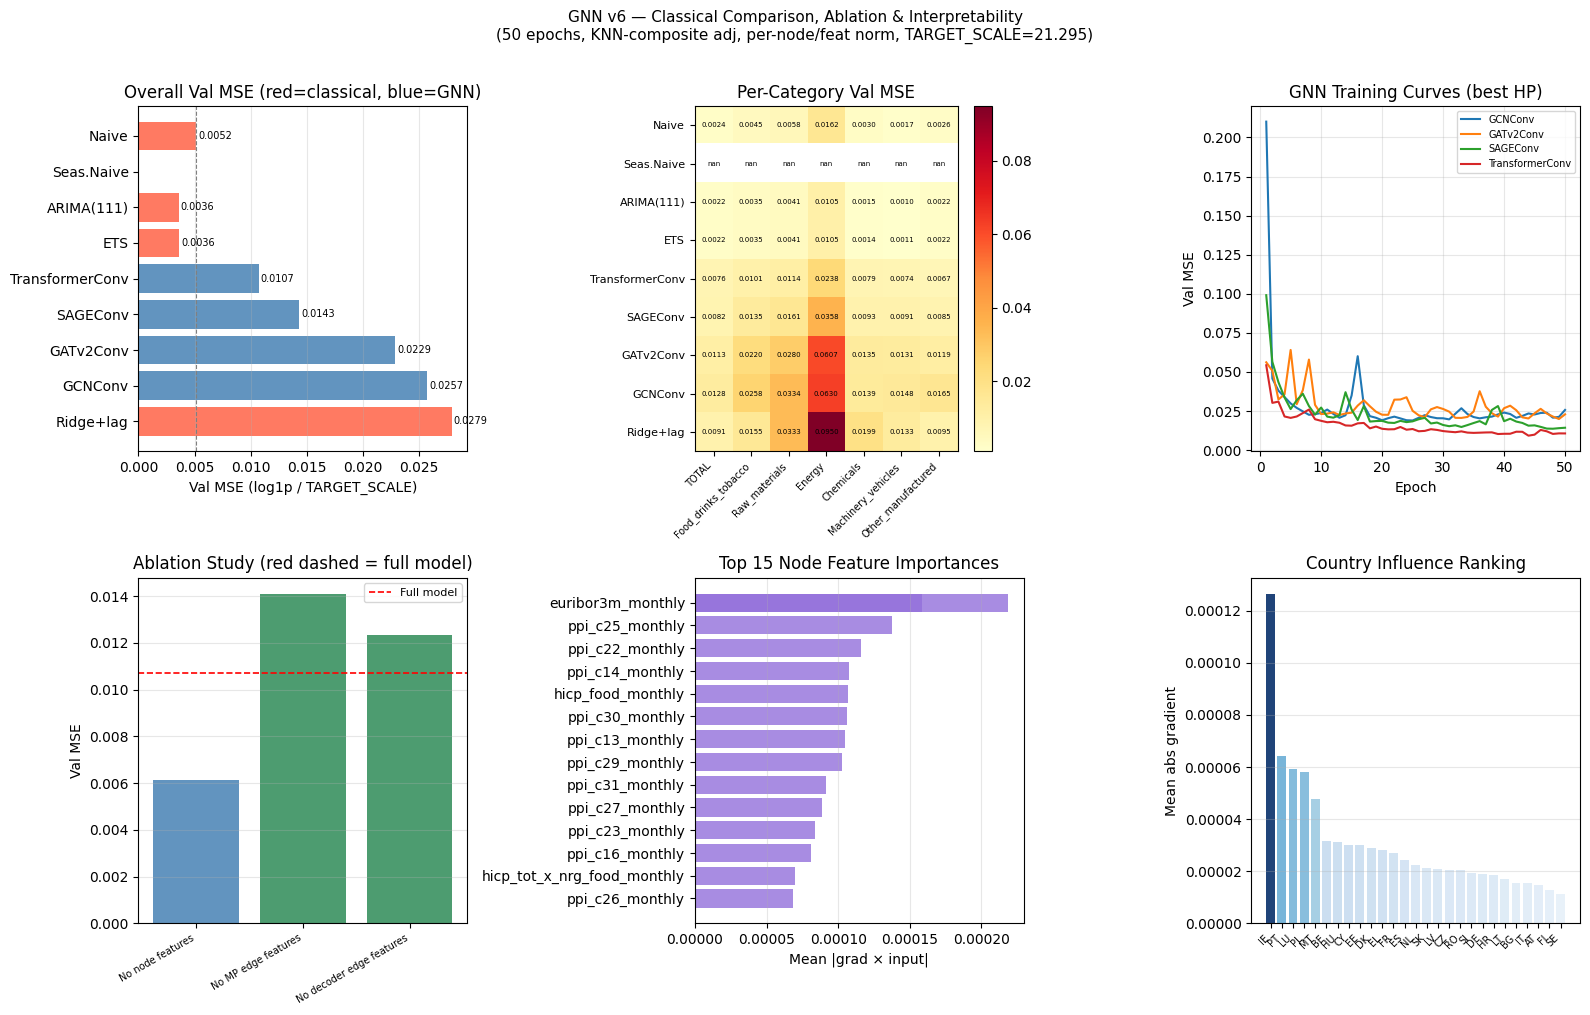

Saved: gnn_v6_master.png


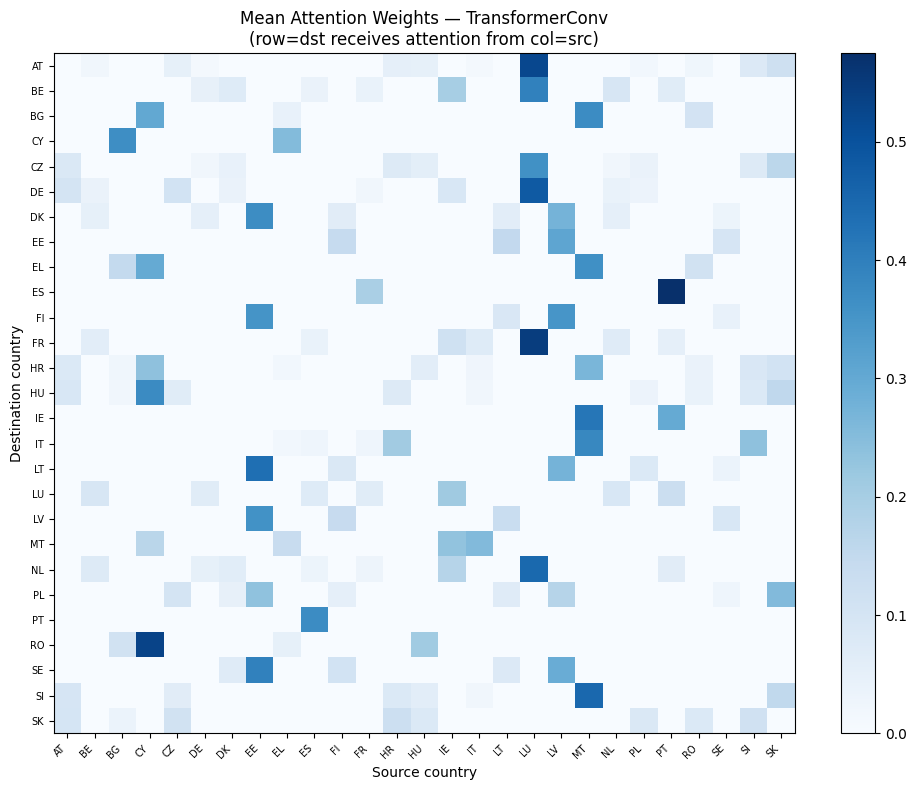

Saved: gnn_v6_attention.png

── Per-country MSE: best GNN vs best classical ──
Country        GNN    ARIMA(111)   GNN better?
──────────────────────────────────────────────────
  AT      0.00498       0.00156             ✗
  BE      0.00942       0.00165             ✗
  BG      0.00870       0.00378             ✗
  CY      0.01699       0.00823             ✗
  CZ      0.00922       0.00170             ✗
  DE      0.00840       0.00119             ✗
  DK      0.00894       0.00232             ✗
  EE      0.00720       0.00303             ✗
  EL      0.01096       0.00268             ✗
  ES      0.01045       0.00214             ✗
  FI      0.01034       0.00316             ✗
  FR      0.00832       0.00132             ✗
  HR      0.01862       0.01421             ✗
  HU      0.01121       0.00293             ✗
  IE      0.01883       0.00485             ✗
  IT      0.00695       0.00125             ✗
  LT      0.00588       0.00241             ✗
  LU      0.01425       0.00564          

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell M — Results Comparison + Error Analysis + Visualizations  (v6)
# ══════════════════════════════════════════════════════════════════════════════

# ── M.1 Master comparison table ───────────────────────────────────────────────
all_methods = {**classical_mse, **gnn_val_mse}
all_preds_np = {**{n: p for n, p in classical_preds.items()},
                **{n: gnn_results[n]['preds'] for n in gnn_val_mse}}
all_cat_mse  = {**classical_mse_cat,
                **{n: gnn_results[n]['mse_per_cat'] for n in gnn_val_mse}}

sorted_methods = sorted(all_methods.items(), key=lambda x: x[1])
best_overall   = sorted_methods[0][0]
baseline_mse_v = classical_mse.get('Naive', list(classical_mse.values())[0])

print("═" * 100)
print("  MASTER COMPARISON TABLE — Val MSE in log1p / TARGET_SCALE space")
print("═" * 100)
header = f"{'Method':<20}  {'Overall':>9}  {'vs Naive':>9}" +          "".join(f"  {cat[:9]:>9}" for cat in ALL_CATS)
print(header); print("─" * 100)
for name, overall in sorted_methods:
    vs_naive   = log_ratio_score(overall, baseline_mse_v)
    cat_vals   = "".join(f"  {all_cat_mse[name].get(cat, float('nan')):>9.5f}" for cat in ALL_CATS)
    marker     = " ◀ BEST" if name == best_overall else ""
    print(f"  {name:<18}  {overall:>9.5f}  {vs_naive:>+9.4f}{cat_vals}{marker}")
print("═" * 100)
print(f"  vs Naive: log-ratio  positive = beats Naive baseline")

# ── M.2 Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Overall MSE bar chart
ax = axes[0, 0]
names_sorted = [n for n, _ in sorted_methods]
vals_sorted  = [v for _, v in sorted_methods]
colors_bar   = ['tomato' if n in classical_mse else 'steelblue' for n in names_sorted]
bars = ax.barh(names_sorted, vals_sorted, color=colors_bar, alpha=0.85)
ax.set_xlabel("Val MSE (log1p / TARGET_SCALE)"); ax.set_title("Overall Val MSE (red=classical, blue=GNN)")
ax.axvline(x=classical_mse.get('Naive',0), color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, vals_sorted):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=7)
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)

# Panel 2: Per-category MSE heatmap
ax = axes[0, 1]
method_names  = [n for n, _ in sorted_methods]
cat_matrix    = np.array([[all_cat_mse[n].get(cat, np.nan) for cat in ALL_CATS]
                           for n in method_names])
im = ax.imshow(cat_matrix, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(N_CATS)); ax.set_xticklabels(ALL_CATS, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(method_names))); ax.set_yticklabels(method_names, fontsize=8)
ax.set_title("Per-Category Val MSE"); plt.colorbar(im, ax=ax)
for i in range(len(method_names)):
    for j in range(N_CATS):
        ax.text(j, i, f"{cat_matrix[i,j]:.4f}", ha='center', va='center', fontsize=5)

# Panel 3: GNN training curves
ax = axes[0, 2]
for name, res in gnn_results.items():
    ax.plot(range(1, len(res['val_hist'])+1), res['val_hist'], label=name, linewidth=1.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val MSE"); ax.set_title("GNN Training Curves (best HP)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 4: Ablation bar chart
ax = axes[1, 0]
abl_names = list(ablation_results.keys())
abl_mses  = [ablation_results[n]['mse'] for n in abl_names]
abl_colors= ['seagreen' if ablation_results[n]['mse'] >= gnn_val_mse[best_gnn_name] else 'steelblue'
              for n in abl_names]
ax.bar(range(len(abl_names)), abl_mses, color=abl_colors, alpha=0.85)
ax.axhline(gnn_val_mse[best_gnn_name], color='red', linestyle='--', linewidth=1.2, label='Full model')
ax.set_xticks(range(len(abl_names))); ax.set_xticklabels(abl_names, rotation=30, ha='right', fontsize=7)
ax.set_ylabel("Val MSE"); ax.set_title("Ablation Study (red dashed = full model)")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Panel 5: Feature importance
ax = axes[1, 1]
top_n = 15
top_feats = sorted(enumerate(interp_results['feat_importance']), key=lambda x: -x[1])[:top_n]
feat_labels = [interp_results['feat_names'][i] if i < len(interp_results['feat_names'])
               else f"feat_{i}" for i, _ in top_feats]
feat_scores = [s for _, s in top_feats]
ax.barh(feat_labels[::-1], feat_scores[::-1], color='mediumpurple', alpha=0.8)
ax.set_xlabel("Mean |grad × input|"); ax.set_title(f"Top {top_n} Node Feature Importances")
ax.grid(axis='x', alpha=0.3)

# Panel 6: Country importance
ax = axes[1, 2]
c_names  = [c for c, _ in interp_results['country_ranked']]
c_scores = [s for _, s in interp_results['country_ranked']]
c_colors = plt.cm.Blues(np.array(c_scores) / max(c_scores))
ax.bar(range(N), c_scores, color=c_colors, alpha=0.9)
ax.set_xticks(range(N)); ax.set_xticklabels(c_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("Mean abs gradient"); ax.set_title("Country Influence Ranking")
ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f"GNN v6 — Classical Comparison, Ablation & Interpretability\n"
    f"({N_EPOCHS} epochs, KNN-composite adj, per-node/feat norm, TARGET_SCALE={TARGET_SCALE:.3f})",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig('gnn_v6_master.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: gnn_v6_master.png")

# ── M.3 Attention heatmap (if GATv2/Transformer) ──────────────────────────────
if interp_results['attn_matrix'] is not None:
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    im2 = ax2.imshow(interp_results['attn_matrix'], cmap='Blues', aspect='auto')
    ax2.set_xticks(range(N)); ax2.set_xticklabels(COUNTRIES, rotation=45, ha='right', fontsize=7)
    ax2.set_yticks(range(N)); ax2.set_yticklabels(COUNTRIES, fontsize=7)
    ax2.set_xlabel("Source country"); ax2.set_ylabel("Destination country")
    ax2.set_title(f"Mean Attention Weights — {best_gnn_name}\n"
                   "(row=dst receives attention from col=src)")
    plt.colorbar(im2, ax=ax2)
    plt.tight_layout()
    plt.savefig('gnn_v6_attention.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("Saved: gnn_v6_attention.png")

# ── M.4 Error breakdown: by country and by trade volume ───────────────────────
print("\n── Per-country MSE: best GNN vs best classical ──")
best_classical    = min(classical_mse, key=classical_mse.get)
gnn_country_mse   = gnn_results[best_gnn_name]['mse_per_country']
class_country_mse = classical_mse_ctr[best_classical]
print(f"{'Country':<6}  {'GNN':>9}  {best_classical:>12}  {'GNN better?':>12}")
print("─" * 50)
for country in COUNTRIES:
    gnn_v  = gnn_country_mse.get(country, np.nan)
    cls_v  = class_country_mse.get(country, np.nan)
    better = "✓" if gnn_v < cls_v else "✗"
    print(f"  {country:<4}  {gnn_v:>9.5f}  {cls_v:>12.5f}  {better:>12}")

# ── M.5 Detransform sample predictions ────────────────────────────────────────
print("\n── Detransform sample: best GNN predictions in EUR ──")
t_demo  = val_idx[len(val_idx) // 2]
ts_demo = common_time[t_demo + 1].strftime('%Y-%m')
print(f"Timestep: {ts_demo}")
print(f"  {'Edge':<10}  {'Pred EUR M (TOTAL)':>20}  {'Actual EUR M':>14}  {'Rel err':>9}")
print("  " + "─" * 58)
for rank, e_idx in enumerate(np.argsort(interp_results['edge_mse'])[:8]):   # easiest-to-predict edges
    s, d    = edge_pairs[e_idx]
    pred_sc = gnn_preds_val[val_idx.index(t_demo), e_idx, 0]
    act_sc  = val_actual[val_idx.index(t_demo), e_idx, 0]
    if np.isnan(act_sc):
        continue
    pred_eur = float(detransform(torch.tensor(pred_sc)).item()) / 1e6
    act_eur  = float(detransform(torch.tensor(act_sc)).item()) / 1e6
    rel_err  = abs(pred_eur - act_eur) / (abs(act_eur) + 1e-6)
    print(f"  {COUNTRIES[s]}→{COUNTRIES[d]:<6}  {pred_eur:>20,.0f}  {act_eur:>14,.0f}  {rel_err:>9.2%}")
print("\n✓ Comparison and error analysis complete")